# Собираем master-датасет для дальнейшей разметки моделью

In [1]:
from datetime import datetime, timezone
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import pandas as pd
from datasets import DatasetDict, load_dataset
from huggingface_hub import HfApi

SOURCE_REPO_ID = "vsevolod-nv/aiconf-butterfly-detection-all"
TARGET_REPO_ID = "vsevolod-nv/aiconf-butterfly-learn-for-model-to-markup"
OUTPUT_DIR = Path("learn_master_dataset")

POSITIVE_CLASS = "butterfly"
POSITIVE_TARGET = 500
NEGATIVE_TARGET = 500
NEGATIVE_CLASSES = ["bee", "beetle", "flower", "shrub"]
RANDOM_STATE = 42

if NEGATIVE_TARGET % len(NEGATIVE_CLASSES) != 0:
    raise ValueError("NEGATIVE_TARGET должен делиться на число негативных классов без остатка")

NEGATIVE_PER_CLASS = NEGATIVE_TARGET // len(NEGATIVE_CLASSES)

print("SOURCE_REPO_ID =", SOURCE_REPO_ID)
print("TARGET_REPO_ID =", TARGET_REPO_ID)
print("NEGATIVE_PER_CLASS =", NEGATIVE_PER_CLASS)

SOURCE_REPO_ID = vsevolod-nv/aiconf-butterfly-detection-all
TARGET_REPO_ID = vsevolod-nv/aiconf-butterfly-learn-for-model-to-markup
NEGATIVE_PER_CLASS = 125


In [2]:
hf = load_dataset(SOURCE_REPO_ID)

if isinstance(hf, DatasetDict):
    source_df = pd.concat(
        [hf[split_name].to_pandas().assign(source_split=split_name) for split_name in hf.keys()],
        ignore_index=True,
    )
else:
    source_df = hf.to_pandas().assign(source_split="train")

if "photo_url" in source_df.columns and "image" not in source_df.columns:
    source_df["image"] = source_df["photo_url"]
if "taxon" in source_df.columns and "entity" not in source_df.columns:
    source_df["entity"] = source_df["taxon"]

required_columns = ["photo_id", "image", "entity"]
missing_columns = [column for column in required_columns if column not in source_df.columns]
if missing_columns:
    raise ValueError(f"В исходном датасете не хватает колонок: {missing_columns}")

base_columns = [
    column
    for column in ["photo_id", "image", "entity", "hard", "photo_url", "taxon", "source_split"]
    if column in source_df.columns
]

source_df = source_df[base_columns].copy()
source_df["photo_id"] = source_df["photo_id"].astype(str)
source_df = source_df.dropna(subset=["photo_id", "image", "entity"])
source_df = source_df.drop_duplicates(subset=["photo_id"]).reset_index(drop=True)

display(source_df.head())
display(source_df["entity"].value_counts().sort_index().rename_axis("entity").reset_index(name="count"))

,photo_id,image,entity,hard,photo_url,taxon,source_split
0,624882867,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,False,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,train
1,624827294,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,True,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,train
2,624825448,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,False,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,train
3,624817355,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,False,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,train
4,624808527,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,False,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,train


,entity,count
0,bee,200
1,beetle,200
2,butterfly,1000
3,flower,200
4,shrub,200


,metric,value
0,total_rows,1000
1,positive_rows,500
2,negative_rows,500


,entity,count
0,bee,125
1,beetle,125
2,butterfly,500
3,flower,125
4,shrub,125


,photo_id,image,entity,hard,photo_url,taxon,source_split,selection_group,target_label,needs_bbox_markup
0,624779576,https://inaturalist-open-data.s3.amazonaws.com...,bee,False,https://inaturalist-open-data.s3.amazonaws.com...,bee,train,negative,negative,False
1,624274153,https://inaturalist-open-data.s3.amazonaws.com...,beetle,False,https://inaturalist-open-data.s3.amazonaws.com...,beetle,train,negative,negative,False
2,624469142,https://inaturalist-open-data.s3.amazonaws.com...,beetle,True,https://inaturalist-open-data.s3.amazonaws.com...,beetle,train,negative,negative,False
3,624549626,https://inaturalist-open-data.s3.amazonaws.com...,beetle,False,https://inaturalist-open-data.s3.amazonaws.com...,beetle,train,negative,negative,False
4,620141299,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,False,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,train,positive,butterfly,True


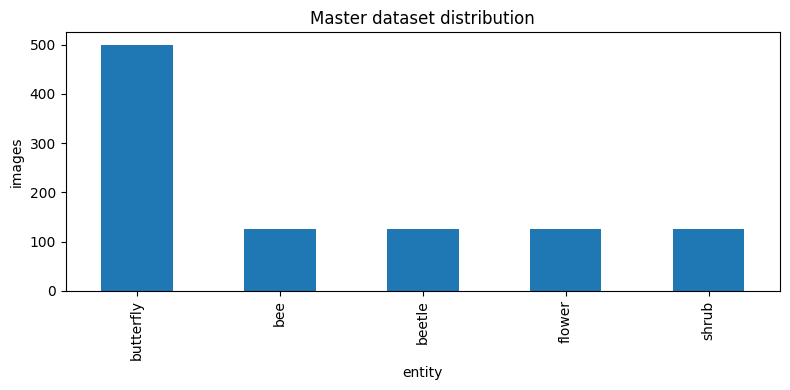

In [3]:
positive_pool = source_df.loc[source_df["entity"].eq(POSITIVE_CLASS)].copy()
negative_pool = source_df.loc[source_df["entity"].isin(NEGATIVE_CLASSES)].copy()

if len(positive_pool) < POSITIVE_TARGET:
    raise ValueError(f"Недостаточно бабочек: нужно {POSITIVE_TARGET}, доступно {len(positive_pool)}")

for negative_class in NEGATIVE_CLASSES:
    class_count = int(negative_pool["entity"].eq(negative_class).sum())
    if class_count < NEGATIVE_PER_CLASS:
        raise ValueError(
            f"Недостаточно примеров класса {negative_class}: нужно {NEGATIVE_PER_CLASS}, доступно {class_count}"
        )

positive_df = positive_pool.sample(n=POSITIVE_TARGET, random_state=RANDOM_STATE).copy()
positive_df["selection_group"] = "positive"

negative_parts = []
for negative_class in NEGATIVE_CLASSES:
    part = negative_pool.loc[negative_pool["entity"].eq(negative_class)].sample(
        n=NEGATIVE_PER_CLASS,
        random_state=RANDOM_STATE,
    ).copy()
    part["selection_group"] = "negative"
    negative_parts.append(part)

negative_df = pd.concat(negative_parts, ignore_index=True)

master_df = pd.concat([positive_df, negative_df], ignore_index=True)
master_df["target_label"] = master_df["entity"].where(master_df["entity"].eq(POSITIVE_CLASS), "negative")
master_df["needs_bbox_markup"] = master_df["entity"].eq(POSITIVE_CLASS)
master_df = master_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

summary_df = pd.concat(
    [
        master_df["entity"].value_counts().sort_index().rename("count"),
        master_df["target_label"].value_counts().sort_index().rename("binary_count"),
    ],
    axis=1,
).fillna(0).astype(int).reset_index().rename(columns={"index": "group"})

display(pd.DataFrame([
    {"metric": "total_rows", "value": len(master_df)},
    {"metric": "positive_rows", "value": int(master_df["entity"].eq(POSITIVE_CLASS).sum())},
    {"metric": "negative_rows", "value": int(master_df["entity"].isin(NEGATIVE_CLASSES).sum())},
]))
display(master_df["entity"].value_counts().sort_index().rename_axis("entity").reset_index(name="count"))
display(master_df.head())

fig, ax = plt.subplots(figsize=(8, 4))
master_df["entity"].value_counts().reindex([POSITIVE_CLASS, *NEGATIVE_CLASSES], fill_value=0).plot(
    kind="bar",
    ax=ax,
    title="Master dataset distribution",
)
ax.set_ylabel("images")
plt.tight_layout()
plt.show()

In [4]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

json_path = OUTPUT_DIR / "master_dataset.json"
tsv_path = OUTPUT_DIR / "master_dataset.tsv"

master_df.to_json(json_path, orient="records", force_ascii=False, indent=2)
master_df.to_csv(tsv_path, sep="\t", index=False)

print("saved:", json_path)
print("saved:", tsv_path)

saved: learn_master_dataset/master_dataset.json
saved: learn_master_dataset/master_dataset.tsv


In [5]:
readme = f"""---
pretty_name: aiconf-butterfly-learn-for-model-to-markup
task_categories:
- image-classification
- object-detection
tags:
- biology
- insects
- butterflies
- inaturalist
---

Master dataset for the next markup stage of butterfly detection.

Sampling rules:
- 500 butterfly images
- 500 negative images
- negative classes are distributed uniformly across: bee, beetle, flower, shrub

Files:
- `master_dataset.json`
- `master_dataset.tsv`

Columns:
- `photo_id`
- `image`
- `entity`
- `selection_group`
- `target_label`
- `needs_bbox_markup`
- `source_split`
- `hard` (if present in source)
- `photo_url` (if present in source)
- `taxon` (if present in source)

Source dataset: `{SOURCE_REPO_ID}`
Generated at: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')}
Rows: {len(master_df)}
"""

api = HfApi()

with TemporaryDirectory() as tmp_dir:
    tmp_path = Path(tmp_dir)
    (tmp_path / "master_dataset.json").write_text(json_path.read_text(encoding="utf-8"), encoding="utf-8")
    (tmp_path / "master_dataset.tsv").write_text(tsv_path.read_text(encoding="utf-8"), encoding="utf-8")
    (tmp_path / "README.md").write_text(readme, encoding="utf-8")

    api.create_repo(repo_id=TARGET_REPO_ID, repo_type="dataset", exist_ok=True)
    api.upload_folder(
        repo_id=TARGET_REPO_ID,
        repo_type="dataset",
        folder_path=str(tmp_path),
        commit_message="Upload master dataset for model-assisted markup",
    )

print(f"Uploaded to: https://huggingface.co/datasets/{TARGET_REPO_ID}")

Uploaded to: https://huggingface.co/datasets/vsevolod-nv/aiconf-butterfly-learn-for-model-to-markup
